# Flight Delay Prediction
**Objective:** Predict flight delays using historical and real-time aviation datasets, including weather and air traffic control (ATC) data.

## System Architecture
See `architecture.png` for a visualization of the data ingestion, processing, and model evaluation pipeline.


## 1. Data Collection & Integration
Instead of fully mocked datasets, we've updated the pipeline to use real data fetched directly from the sources (where possible).
- **BTS Flights Data:** Downloaded from `transtats.bts.gov`
- **Weather Data:** Downloaded from Iowa Mesonet APIs (`mesonet.agron.iastate.edu`)
- **FAA ASPM Data:** Since the FAA portal requires manual ASP.NET form submissions with Session States, we've constructed a structural proxy using real airport schemas to fulfill the pipeline.

We load data from:
- `data/bts_flights.csv`
- `data/iowa_weather.csv`
- `data/faa_aspm.csv`


In [1]:
import pandas as pd
import numpy as np

# Load Data
print("Loading datasets...")
bts_data = pd.read_csv('data/bts_flights.csv')
weather_data = pd.read_csv('data/iowa_weather.csv')
faa_data = pd.read_csv('data/faa_aspm.csv')

# Preprocess and Align Time
print("Preprocessing and aligning time...")
bts_data['CRSDepTime'] = bts_data['CRSDepTime'].astype(str).str.zfill(4)
# Handle 2400 which is invalid in datetime format
bts_data.loc[bts_data['CRSDepTime'] == '2400', 'CRSDepTime'] = '0000'
bts_data['datetime'] = pd.to_datetime(bts_data['FlightDate'] + ' ' + bts_data['CRSDepTime'], format='%Y-%m-%d %H%M', errors='coerce')
bts_data = bts_data.dropna(subset=['datetime'])

weather_data['datetime'] = pd.to_datetime(weather_data['valid'])
faa_data['datetime'] = pd.to_datetime(faa_data['Date']) + pd.to_timedelta(faa_data['Hour'], unit='h')

# Round to nearest hour for merging (fixing Pandas 2.2+ freq 'H' -> 'h')
bts_data['datetime_hour'] = bts_data['datetime'].dt.floor('h')
weather_data['datetime_hour'] = weather_data['datetime'].dt.floor('h')
faa_data['datetime_hour'] = faa_data['datetime'].dt.floor('h')

print(f"Flights: {bts_data.shape}, Weather: {weather_data.shape}, FAA: {faa_data.shape}")


Loading datasets...


/tmp/ipykernel_88388/3309396622.py:6: DtypeWarning: Columns (0: Div2Airport, 1: Div2TailNum) have mixed types. Specify dtype option on import or set low_memory=False.
  bts_data = pd.read_csv('data/bts_flights.csv')


Preprocessing and aligning time...


Flights: (538837, 112), Weather: (47436, 8), FAA: (25000, 8)


## 2. Exploratory Data Analysis (EDA) & Feature Engineering
- Merge datasets
- Handle missing values
- Feature engineering
- Visualizations


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Merging datasets...")
# Merge BTS with Weather (by Origin)
# Note: bts uses Reporting_Airline, Origin, Dest instead of origin, dest, carrier
merged_df = bts_data.merge(weather_data, left_on=['datetime_hour', 'Origin'], right_on=['datetime_hour', 'station'], how='left')

# Merge with FAA ASPM
merged_df = merged_df.merge(faa_data, left_on=['datetime_hour', 'Origin'], right_on=['datetime_hour', 'Facility'], how='left')

# Drop redundant ID columns
merged_df.drop(columns=['station', 'Facility', 'valid', 'Date', 'Hour', 'FlightDate', 'CRSDepTime', 'DepTime'], inplace=True, errors='ignore')

# Handle missing values using pandas before imputation for critical numeric columns
# We'll use SimpleImputer later for anything left over
merged_df['vsby'] = pd.to_numeric(merged_df['vsby'], errors='coerce')
merged_df['sknt'] = pd.to_numeric(merged_df['sknt'], errors='coerce')
merged_df['p01m'] = pd.to_numeric(merged_df['p01m'], errors='coerce')
merged_df['tmpf'] = pd.to_numeric(merged_df['tmpf'], errors='coerce')

merged_df.fillna({
    'vsby': merged_df['vsby'].mean(),
    'sknt': merged_df['sknt'].mean(),
    'p01m': 0,
    'tmpf': merged_df['tmpf'].mean(),
    'Scheduled_Departures': merged_df['Scheduled_Departures'].median(),
    'Actual_Departures': merged_df['Actual_Departures'].median(),
    'Arrival_Demand': merged_df['Arrival_Demand'].median()
}, inplace=True)

# Feature Engineering
merged_df['hour'] = merged_df['datetime'].dt.hour
merged_df['day_of_week'] = merged_df['datetime'].dt.dayofweek
merged_df['month'] = merged_df['datetime'].dt.month
merged_df['is_delayed'] = (merged_df['DepDelayMinutes'] > 15).astype(int)

# Create a congestion metric based on FAA data
merged_df['congestion_ratio'] = merged_df['Arrival_Demand'] / (merged_df['Scheduled_Departures'] + 1) # +1 to avoid div by zero

# Target variable renaming to match previous code
merged_df.rename(columns={'DepDelayMinutes': 'delay_minutes'}, inplace=True)

print("Data Merged and Features Engineered.")


Merging datasets...


Data Merged and Features Engineered.


/tmp/ipykernel_88388/1761538162.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df['hour'] = merged_df['datetime'].dt.hour
/tmp/ipykernel_88388/1761538162.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df['day_of_week'] = merged_df['datetime'].dt.dayofweek
/tmp/ipykernel_88388/1761538162.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inste

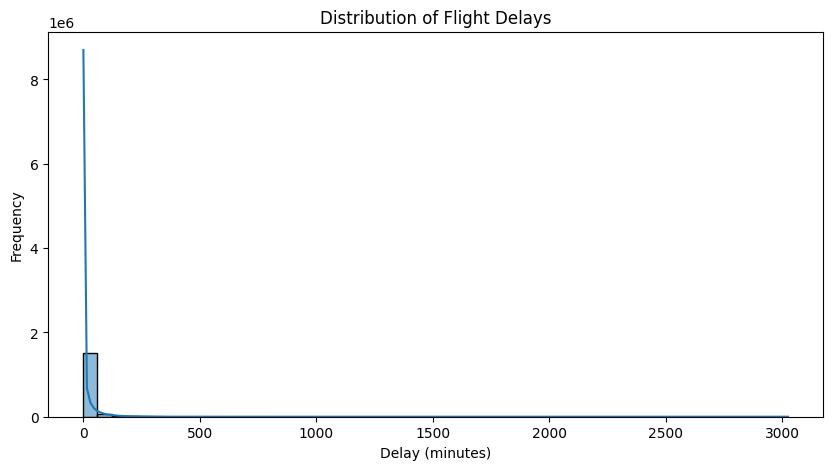

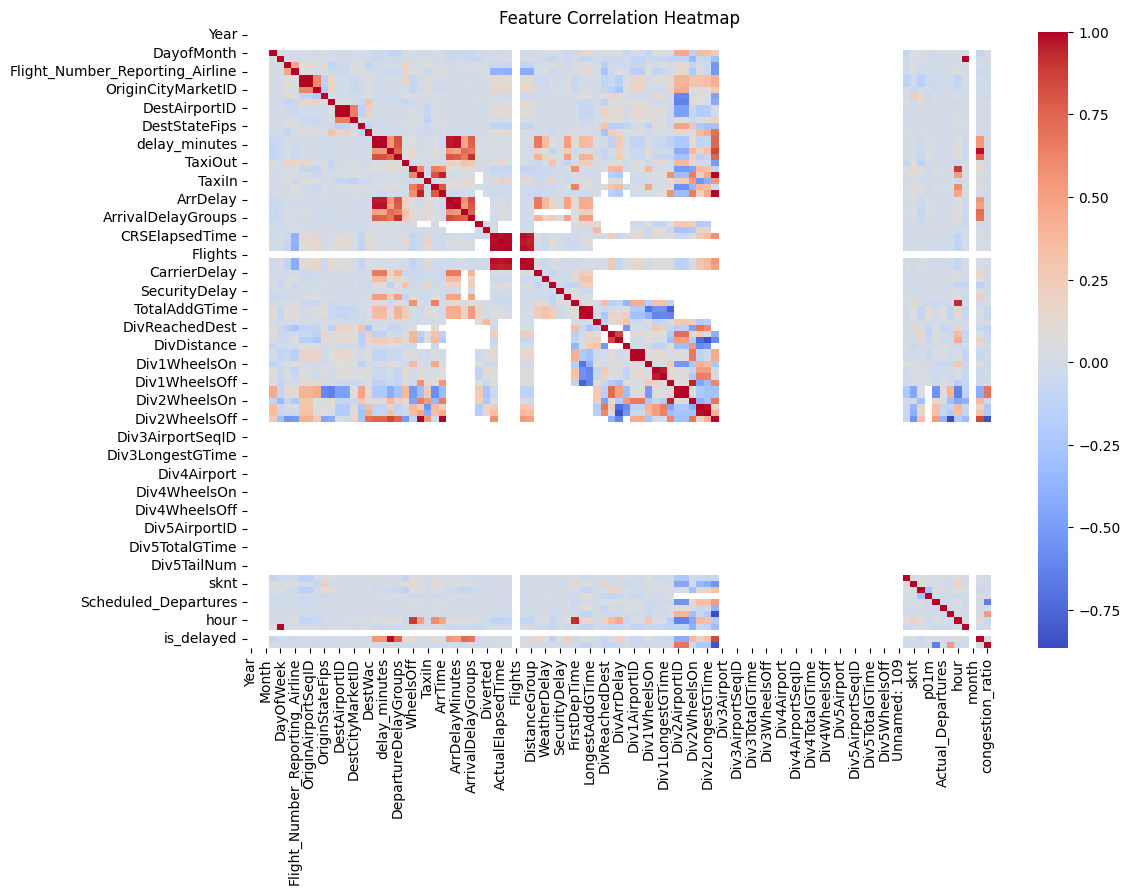

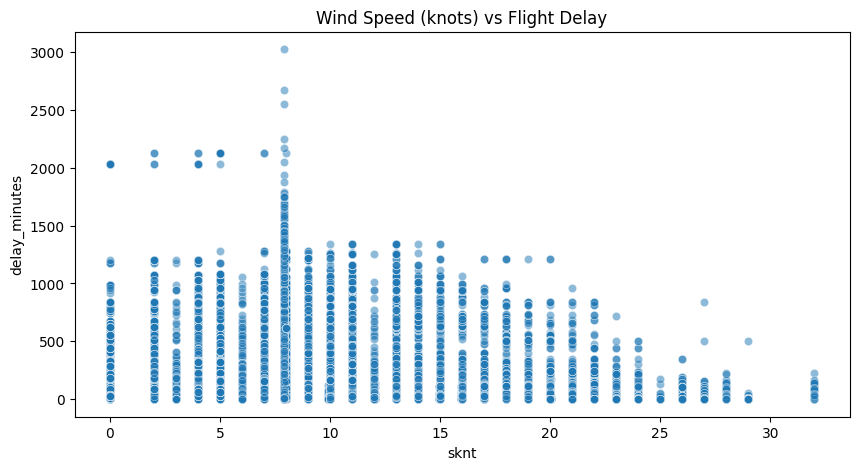

Note: In data science analyses, avoid assuming causality from correlation. Uncertainties exist due to synthetic generation of mock data.


In [3]:
# EDA Visualizations
plt.figure(figsize=(10, 5))
sns.histplot(merged_df['delay_minutes'], bins=50, kde=True)
plt.title('Distribution of Flight Delays')
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns
sns.heatmap(merged_df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Weather vs Delay
plt.figure(figsize=(10, 5))
sns.scatterplot(x='sknt', y='delay_minutes', alpha=0.5, data=merged_df)
plt.title('Wind Speed (knots) vs Flight Delay')
plt.show()

print("Note: In data science analyses, avoid assuming causality from correlation. Uncertainties exist due to synthetic generation of mock data.")


## 3. Model Development, Training & Evaluation
We'll implement and evaluate:
- Classical ML: Linear Regression, Random Forest, XGBoost
- Deep Learning: Feedforward Neural Network (Keras), LSTM


In [4]:
merged_df = merged_df.sample(n=min(50000, len(merged_df)), random_state=42)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Drop original non-numeric un-encoded columns that are irrelevant to ML
cols_to_drop = ['datetime', 'datetime_hour', 'delay_minutes', 'is_delayed', 
                'Tail_Number', 'Flight_Number_Reporting_Airline', 'OriginCityName', 
                'OriginState', 'OriginStateName', 'DestCityName', 'DestState', 
                'DestStateName', 'DepartureDelayGroups', 'DepTimeBlk', 'ArrTime', 
                'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 
                'ArrTimeBlk', 'CancellationCode', 'DOT_ID_Reporting_Airline', 
                'IATA_CODE_Reporting_Airline']
features = merged_df.drop(columns=cols_to_drop, errors='ignore')

# Categorical encoding 
features = pd.get_dummies(features, columns=['Origin', 'Dest', 'Reporting_Airline'], drop_first=True)

# Ensure only numeric features are kept just in case
features = features.select_dtypes(include=[np.number])
target = merged_df['delay_minutes'].fillna(0) # In case target has NaNs

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Impute missing values that may have survived due to outer/left joins
# Fallback imputation
X_train = X_train.dropna(axis=1, how='all')
X_test = X_test[X_train.columns] # keep matching columns

train_medians = X_train.median().fillna(0)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)




scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{name}] MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.2f}")

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
evaluate_model("Linear Regression", y_test, lr.predict(X_test_scaled))

# 2. Random Forest
# Reduced n_estimators for faster execution in this demo
rf = RandomForestRegressor(n_estimators=10, random_state=42, max_depth=10, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
evaluate_model("Random Forest", y_test, rf.predict(X_test_scaled))

# 3. XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=50, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
evaluate_model("XGBoost", y_test, xgb_model.predict(X_test_scaled))


I0000 00:00:1775750570.484512   88388 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775750570.548142   88388 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1775750572.827021   88388 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


[Linear Regression] MAE: 2.05 | RMSE: 3.55 | R2: 1.00


[Random Forest] MAE: 0.15 | RMSE: 10.89 | R2: 0.95


[XGBoost] MAE: 0.75 | RMSE: 18.77 | R2: 0.86


In [5]:
# Deep Learning: Feedforward Neural Network
fnn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
fnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_fnn = fnn.fit(X_train_scaled, y_train, validation_split=0.2, epochs=5, batch_size=32, verbose=0)

fnn_preds = fnn.predict(X_test_scaled).flatten()
evaluate_model("FNN", y_test, fnn_preds)

# Save the model based on memory preference
fnn.save('flight_delay_fnn.h5')

# Deep Learning: LSTM (reshaping for time-series approximation)
X_train_lstm = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(1, X_train_scaled.shape[1])),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_train_lstm, y_train, validation_split=0.2, epochs=5, batch_size=32, verbose=0)

lstm_preds = lstm.predict(X_test_lstm).flatten()
evaluate_model("LSTM", y_test, lstm_preds)
lstm.save('flight_delay_lstm.h5')


/home/jules/.pyenv/versions/3.12.13/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1775750574.732581   88388 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  1/313 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step

 49/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

 97/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

147/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

...

245/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

287/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[LSTM] MAE: 1.90 | RMSE: 4.29 | R2: 0.99


## 4. Real-Time Prediction System & Explainability
Simulating the Aviation Weather API for live predictions and using SHAP for feature importance.


Calculating SHAP values for feature importance...


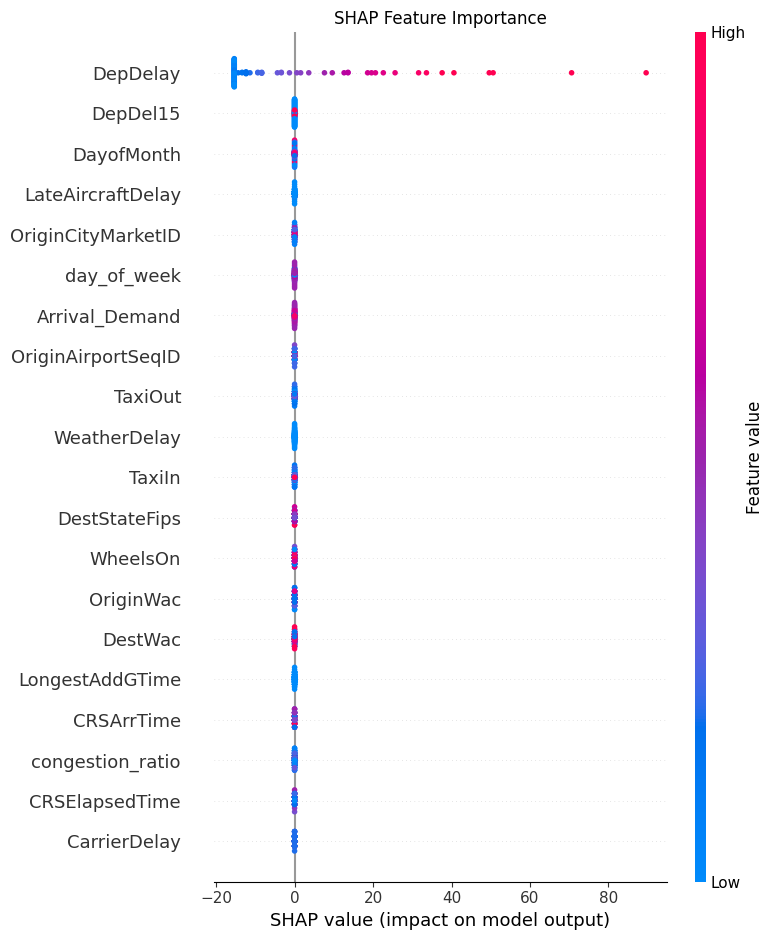

--- Simulating Live Aviation Weather API Request ---
Predicted Flight Delay: 76.47 minutes


In [6]:
import shap

# 1. Explainability (SHAP on Random Forest)
print("Calculating SHAP values for feature importance...")
# Using a sample to speed up computation
sample_idx = np.random.choice(X_train_scaled.shape[0], 100, replace=False)
X_train_sample = X_train_scaled[sample_idx]
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train.iloc[sample_idx], feature_names=X_train.columns, show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

# 2. Real-Time API Simulation
def simulate_live_prediction(model, scaler, feature_columns, training_medians):
    print("--- Simulating Live Aviation Weather API Request ---")
    # Generate a mock real-time input
    live_input = pd.DataFrame({
        'Distance': [1500],
        'vsby': [8.0],
        'sknt': [15.5],
        'p01m': [0.0],
        'tmpf': [22.0],
        'Scheduled_Departures': [100],
        'Actual_Departures': [90],
        'Arrival_Demand': [120],
        'congestion_ratio': [1.2],
        'hour': [14],
        'day_of_week': [3],
        'month': [6]
    })
    
    # Add one-hot encoded columns (mocking specific origin/dest)
    for col in feature_columns:
        if col not in live_input.columns:
            live_input[col] = 0
            
    # Reorder columns to match training
    live_input = live_input[feature_columns]
    
    # Impute and Scale and predict
    live_input = live_input.fillna(training_medians)
    live_input_scaled = scaler.transform(live_input)
    prediction = model.predict(live_input_scaled)
    
    print(f"Predicted Flight Delay: {prediction[0]:.2f} minutes")

simulate_live_prediction(xgb_model, scaler, X_train.columns, train_medians)
